### Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

### Tratamento e visualização inicial dos arquivos

In [2]:
costs_df = pd.read_csv('data/costs_us.csv',
                       parse_dates=['dt']) # dt é um campo de data
orders_log_df = pd.read_csv('data/orders_log_us.csv',
                            parse_dates=['Buy Ts']) # Buy Ts é um campo de data
visits_log_df = pd.read_csv('data/visits_log_us.csv',
                            dtype={'Device':'category'}, # Device é um campo categórico
                            parse_dates=['End Ts', 'Start Ts'])# End Ts e Start Ts são campos de data
# Cada campo foi alterado para o tipo de dado correto

In [3]:
dfs = {
    'costs_df':costs_df, 
    'orders_log_df':orders_log_df, 
    'visits_log_df':visits_log_df}

def clean_data(df_list):
    for df in df_list.values():
        df.columns = [column.lower().replace(' ','_') for column in df.columns]
clean_data(dfs)

for name, df in dfs.items():
    print("====",name.upper(),"INFO ====")
    print(df.info())
    print()
    print("====",name.upper(),"HEAD ====")
    display(df.head())
    print()
    print(f"Linhas duplicadas: {df.duplicated().sum()}")
    print()
# Nessa célula, os dataframes foram padronizados e limpos.
# Além disso foram exibidas as informações de cada um, em prol de entender os dados antes de realizar as analises

==== COSTS_DF INFO ====
<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 59.7 KB
None

==== COSTS_DF HEAD ====


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08



Linhas duplicadas: 0

==== ORDERS_LOG_DF INFO ====
<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[us]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB
None

==== ORDERS_LOG_DF HEAD ====


,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450



Linhas duplicadas: 0

==== VISITS_LOG_DF INFO ====
<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[us]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[us](2), int64(1), uint64(1)
memory usage: 11.3 MB
None

==== VISITS_LOG_DF HEAD ====


,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168



Linhas duplicadas: 0



### Calculo de métricas - PRODUTOS

In [4]:
visits_log_df['session_year'] = visits_log_df['start_ts'].dt.isocalendar().year # Cria uma nova coluna com o ano de cada acesso
visits_log_df['session_month_period'] = visits_log_df['start_ts'].dt.to_period('M') # Cria uma nova coluna com o mes de cada acesso
visits_log_df['session_week'] = visits_log_df['start_ts'].dt.isocalendar().week # Cria uma nova coluna com a semana de cada acesso
visits_log_df['session_date'] = visits_log_df['start_ts'].dt.date # Cria uma nova coluna com a data de cada acesso

# Extrai os usuários unicos por período de tempo
mau_total = visits_log_df.groupby('session_month_period')['uid'].nunique().reset_index()
wau_total = visits_log_df.groupby(['session_year','session_week']).agg(
    n_users=('uid','nunique'),
    week_start=('start_ts','min')).reset_index()
dau_total = visits_log_df.groupby('session_date')['uid'].nunique().reset_index()

# Renomeia as colunas
mau_total.columns = ['month','n_users']
wau_total.columns = ['year','week','n_users','week_start']
dau_total.columns = ['session_date','n_users']
wau_total = wau_total.sort_values('week_start')

# Exibe os valores
print(f"Média de usuários"
      f"\nMensal:{mau_total['n_users'].mean().round(2)}",
      f"\nSemanal:{wau_total['n_users'].mean().round(2)}",
      f"\nDiário:{dau_total['n_users'].mean().round(2)}")


Média de usuários
Mensal:23228.42 
Semanal:5716.25 
Diário:907.99


In [5]:
mau_total['month'] = mau_total['month'].dt.to_timestamp() # Converte a coluna 'month' para o tipo datetime

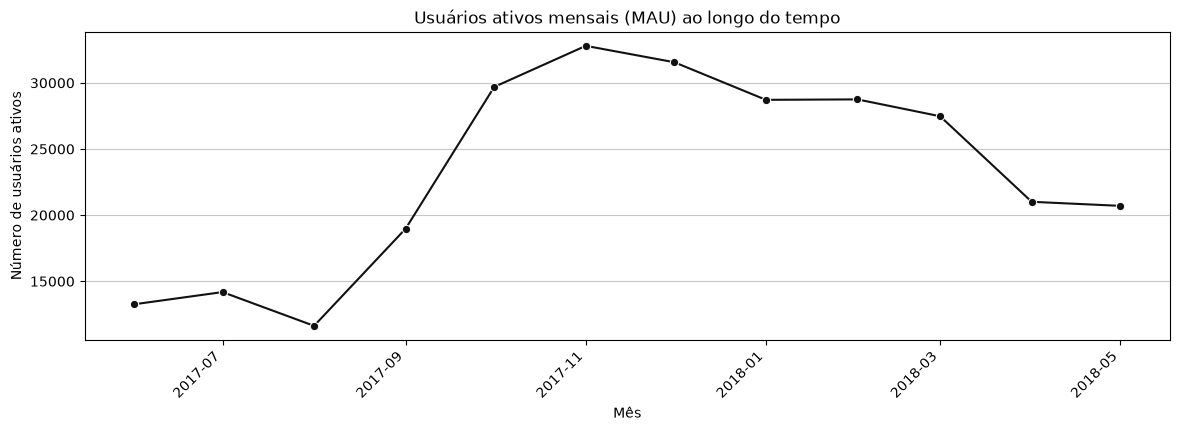

In [6]:
# Visualização dos usuários ativos mensais (MAU) ao longo do tempo
plt.figure(figsize=(14,4))
sns.lineplot(data=mau_total, x='month', y='n_users', marker='o', color='#111111')
plt.xlabel('Mês')
plt.ylabel('Número de usuários ativos')
plt.title('Usuários ativos mensais (MAU) ao longo do tempo')
plt.grid(axis='y', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

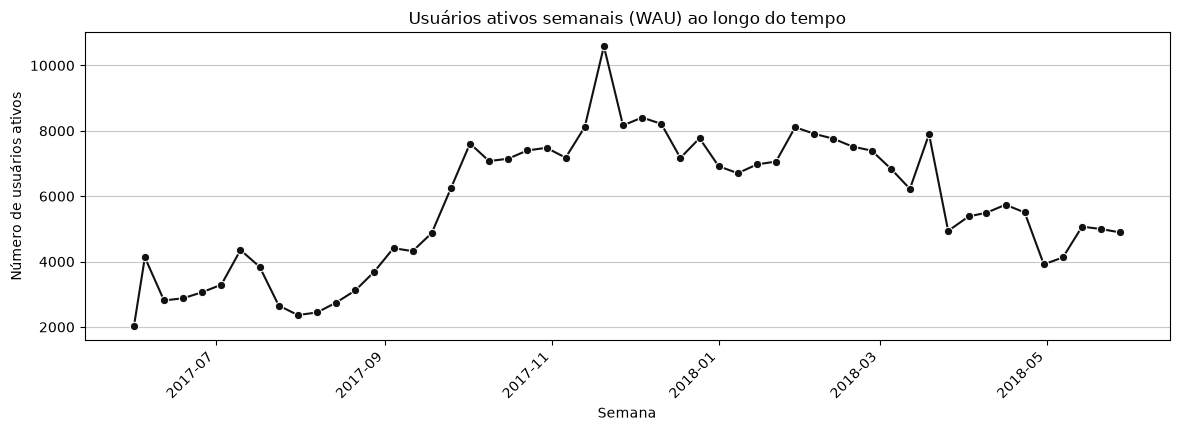

In [7]:
# Visualização dos usuários ativos semanais (WAU) ao longo do tempo
plt.figure(figsize=(14,4))
sns.lineplot(data=wau_total, x='week_start', y='n_users', marker='o', color='#111111')
plt.xlabel('Semana')
plt.ylabel('Número de usuários ativos')
plt.title('Usuários ativos semanais (WAU) ao longo do tempo')
plt.grid(axis='y', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

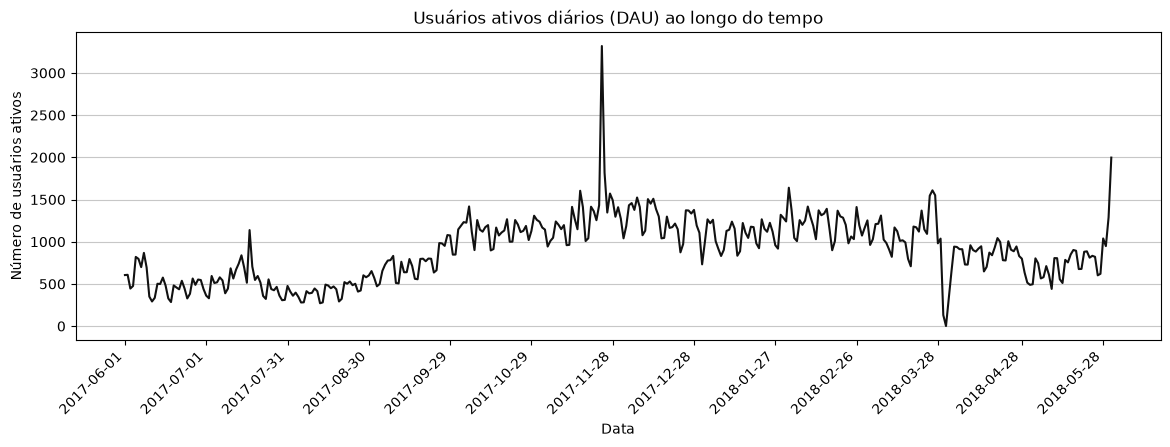

In [8]:
# Visualização dos usuários ativos diários (DAU) ao longo do tempo
plt.figure(figsize=(14,4))
ax = sns.lineplot(data=dau_total, x='session_date', y='n_users', color='#111111')
ax.set_xticks(dau_total['session_date'][::30])
plt.xlabel('Data')
plt.ylabel('Número de usuários ativos')
plt.title('Usuários ativos diários (DAU) ao longo do tempo')
plt.grid(axis='y', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.show()

In [9]:
dau_total['session_date'] = pd.to_datetime(dau_total['session_date']) # Converte a coluna 'session_date' para o tipo datetime
dau_filtered = dau_total[(dau_total['session_date'] >= '2018-03-25') & (dau_total['session_date'] <= '2018-04-5') ] # Filtra os dados para o período de 25/03/2018 a 05/04/2018
print(dau_filtered) # Exibe os dados filtrados, afim de estudar a queda em março de 2018

    session_date  n_users
297   2018-03-25     1545
298   2018-03-26     1609
299   2018-03-27     1551
300   2018-03-28      981
301   2018-03-29     1037
302   2018-03-30      131
303   2018-03-31        1
304   2018-04-02      641
305   2018-04-03      942
306   2018-04-04      938
307   2018-04-05      912


## Observações

### Mês
O gráfico mostra que a quantidade de usuários ativo no mês, durante todo o periodo estudado, basicamente triplica de Agosto de 2017 para novembro do mesmo ano. Após isso temos quedas constantes, mais nada aponta que voltaremos a 10 mil usuários ativos novamente.

### Semana
Juntamente ao gráfico mensal, o gráfico semanal também mostra alta elevada, com um pico de 11 mil acessos em dezembro de 2017, após isso segue em queda gradual.

### Dia
O gráfico de acesso diário nos confirma a média de 907 acessos diários. Iniciamos em torno de ~800 acessos diários, depois temos a mesma alta nas das de fim de ano com um pico no final de novembro de ~3500 acessos, e igual ao restante, seguimos com quedas demorada pelo resto de 2018.\
Em março de 2018 tivemos uma anomalia, zerandos os acessos diários. Estudando de perto, conclui-se que foi uma queda progressiva, seguida de um apagão total por 1 dia e depois uma alta gradual, uma possivel manutenção/instabilidade no sistema de logs que causou isso. Recomenda-se desconsiderar esse intervalo em análises de tendência.

In [10]:
session_per_day = visits_log_df.groupby('session_date').agg({'uid':['count', 'nunique']}) # Realiza a contagem de sessões
session_per_day.columns = ['qty_sessions', 'nunique_users']
session_per_day['sess_per_user'] = session_per_day['qty_sessions'] / session_per_day['nunique_users'] # Retorna a média de acessos por dia
display(session_per_day.head(3))
print(f'Média de acessos geral:',session_per_day['sess_per_user'].mean().round(2),
      f'\nMáxima registrada:',session_per_day['sess_per_user'].max().round(2))

,qty_sessions,nunique_users,sess_per_user
session_date,,,
2017-06-01,664,605,1.097521
2017-06-02,658,608,1.082237
2017-06-03,477,445,1.071910


Média de acessos geral: 1.08 
Máxima registrada: 1.22


No geral, cada cliente acessa o app 1 vez por dia, além disso, em nenhum momento o número de acessos chegou a ser 1.5x maior, registrando uma máxima de 1.22.

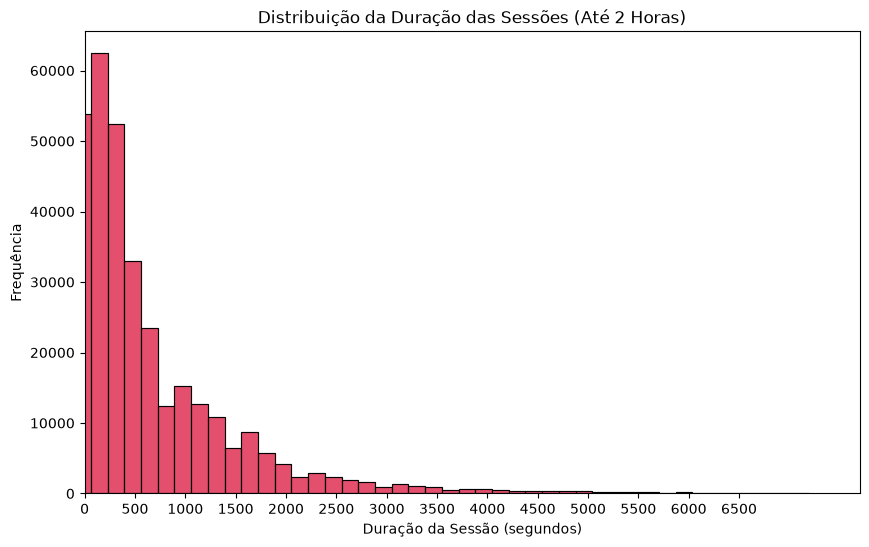

A decisão de manter 7200 segundos (2 horas), foi para comprimir os dados para melhor visualização, pois o eixo X supera os 80.000 segundos (22 horas)


In [11]:
visits_log_df['session_length'] = (visits_log_df['end_ts'] - visits_log_df['start_ts']).dt.total_seconds() # Cria uma nova coluna com a duração de cada sessão em segundos
valid_sessions = visits_log_df[visits_log_df['session_length'] != 0] # Remove os zeros para que não alterem os cálculos
plt.figure(figsize=(10, 6))

# Filtra visualmente até 2 horas (7200 segundos) para detalhar o gráfico
sns.histplot(valid_sessions[valid_sessions['session_length'] <= 7200]['session_length'], bins=60, color='crimson')
plt.xticks(np.arange(0, 7000, 500))
plt.xlim(left=0)
plt.title('Distribuição da Duração das Sessões (Até 2 Horas)')
plt.xlabel('Duração da Sessão (segundos)')
plt.ylabel('Frequência')
plt.show()
print('A decisão de manter 7200 segundos (2 horas), foi para comprimir os dados para melhor visualização, pois o eixo X supera os 80.000 segundos (22 horas)')

A mediana da duração das sessões é de 360 segundos, por outra lado, a moda indica que o valor mais frequente é 60 segundos.\
O Histograma confirma que grande parte do acessos estão proximos de 0.

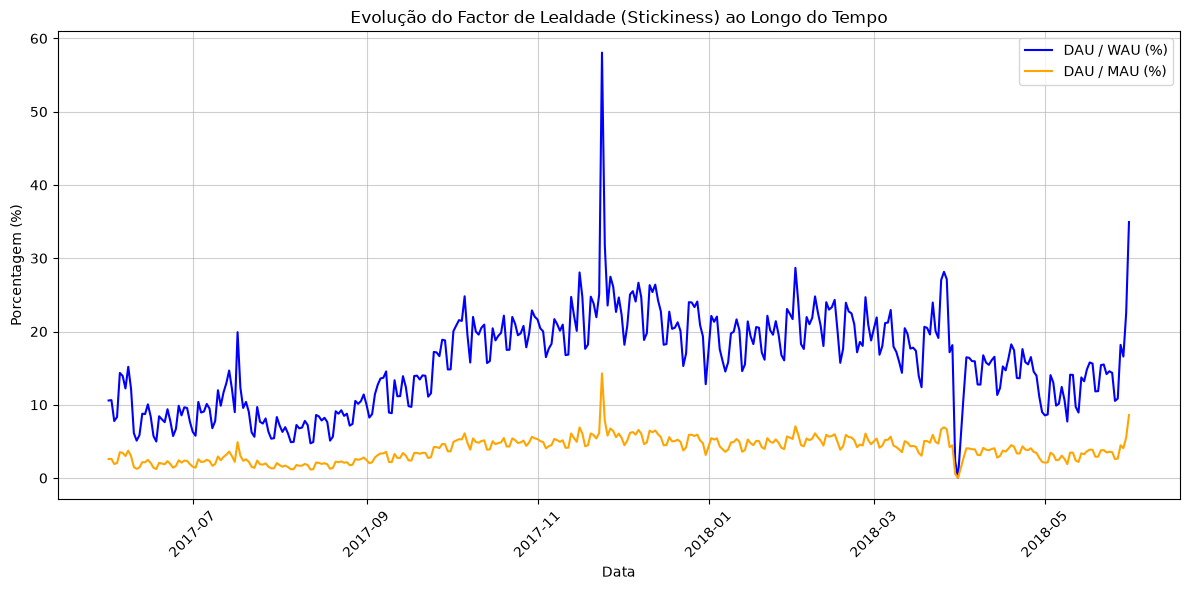

In [12]:
# Cálculo do fator de lealdade (stickiness)
sticky_df = dau_total.copy()
sticky_df['sticky_wau'] = (dau_total['n_users'] / wau_total['n_users'].mean()) * 100
sticky_df['sticky_mau'] = (dau_total['n_users'] / mau_total['n_users'].mean()) * 100

# Visualização do fator de lealdade (stickiness) ao longo do tempo
plt.figure(figsize=(12, 6))
plt.plot(sticky_df['session_date'], sticky_df['sticky_wau'], label='DAU / WAU (%)', color='blue')
plt.plot(sticky_df['session_date'], sticky_df['sticky_mau'], label='DAU / MAU (%)', color='orange')

# Configurações do gráfico
plt.title('Evolução do Factor de Lealdade (Stickiness) ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Porcentagem (%)')
plt.legend()
plt.grid(True, alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico demonstra que a stickiness teve um crescimento a partir de setembro de 2017, com um pico observável em dezembro, chegando proximo aos 58%.\
A lealdade dos clientes se manteve oscilante até o fim dos dados.\
Em março de 2018 tivemos a queda repentina devido a instabilidade do sistema de logs.

## Conclusão das métricas para o produto

- As métricas apontam que tivemos um único pico de 33 mil acessos por mês, e uma variação de ~500 a ~1500 acessos diários.
- A máxima de acessos registrados foi de 1.22, ou seja, em um unico dia, de 100 clientes, tivemos no maximo 122 acessos. O que faz eles acessarem tão pouco? interface ruim? Log out por inatividade?
- Os clientes entram no app, e logo saem, com isso, temos muitas sessões nulas, porém quando o cliente decide ficar, ficam por aproximadamente 6 minutos. O que leva eles a sairem rapidamente? Dificuldades com o log in? Demora para carregar?
- Os usuários semanais visitam o app 1 vez por semana, e os mensais 1 vez por mês, como podemos fazer que visitem mais? Notificações push? Sistema de recompensa por log in? E-mails promocionais?

Vale a pena revisar cada detalhe do app e testar suas funcionalidades, afinal, pra entender o cliente, basta ser um deles.

### Calculo de métricas - VENDAS

In [13]:
first_visit = visits_log_df.groupby('uid')['start_ts'].min() # Data da primeira visita
first_order = orders_log_df.groupby('uid')['buy_ts'].min() # Data da primeira compra
conversion_all = pd.merge(first_order, first_visit, on='uid', how='outer').reset_index() # Junta ambos
conversion_all.columns = ['uid','first_order','first_visit']
conversion_not_null = conversion_all.dropna().reset_index(drop=True) # Remove os ausentes
# A decisão de manter 2 DataFrames, um com ausentes e outro sem, foi para auxiliar em cálculos futuros

# Cria uma nova coluna com a diferença entre a primeira compra e a primeira visita
conversion_not_null['conversion_time'] = (conversion_not_null['first_order'] - conversion_not_null['first_visit']).dt.days
display(conversion_not_null.head(3))
not_insta_conversion = conversion_not_null[conversion_not_null['conversion_time'] > 0]
# Verificando se há possiveis bugs de log em que a compra foi feita antes da visita
no_buy = conversion_all[conversion_all['first_order'].isna()]  # visitou, nunca comprou
no_visit = conversion_all[conversion_all['first_visit'].isna()]  # comprou, sem visita registrada
print(f"O tempo mediano de conversão é de {conversion_not_null['conversion_time'].median()} dias"
      f"\nO tempo mínimo é de {conversion_not_null['conversion_time'].min()} dias"
      f"\nO tempo médio de conversão dos clientes que não compram na data do registro é {not_insta_conversion['conversion_time'].mean().round(2)} dias"
      f"\nUsuários sem compra registrada: {len(no_buy)}"
      f"\nUsuários com compra mas sem visita registrada: {len(no_visit)}")

,uid,first_order,first_visit,conversion_time
0,313578113262317,2018-01-03 21:51:00,2017-09-18 22:49:00,106
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0
2,2429014661409475,2017-10-11 18:33:00,2017-10-11 17:14:00,0


O tempo mediano de conversão é de 0.0 dias
O tempo mínimo é de 0 dias
O tempo médio de conversão dos clientes que não compram na data do registro é 60.14 dias
Usuários sem compra registrada: 191646
Usuários com compra mas sem visita registrada: 0


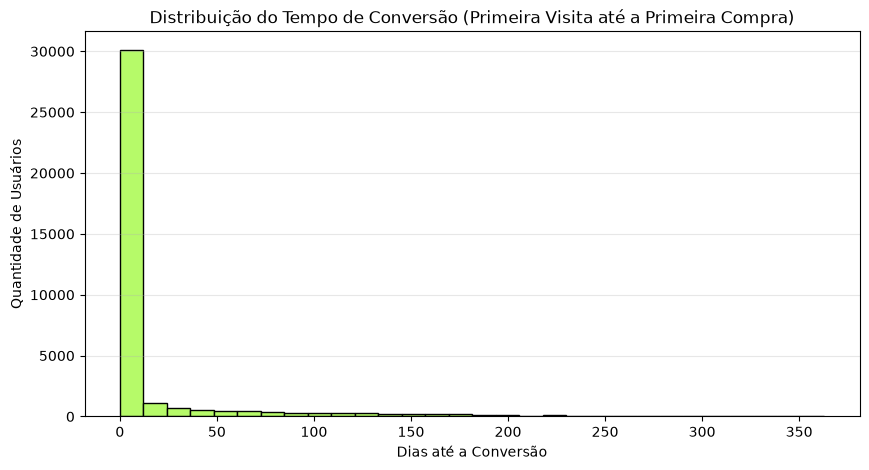

In [14]:
# Visualização da distribuição do tempo de conversão (primeira visita até a primeira compra)
plt.figure(figsize=(10, 5))
plt.hist(
    conversion_not_null['conversion_time'],
    bins=30,
    color="#B6FA69",
    edgecolor='black',
)

# Configurações do gráfico
plt.title('Distribuição do Tempo de Conversão (Primeira Visita até a Primeira Compra)')
plt.xlabel('Dias até a Conversão')
plt.ylabel('Quantidade de Usuários')
plt.grid(axis='y', alpha=0.3)
plt.show()

O histograma confirma que a maioria das conversões ocorre no dia da primeira visita, porém existe uma cauda longa que mostra que alguns utilizadores levam até 60 dias para converter.

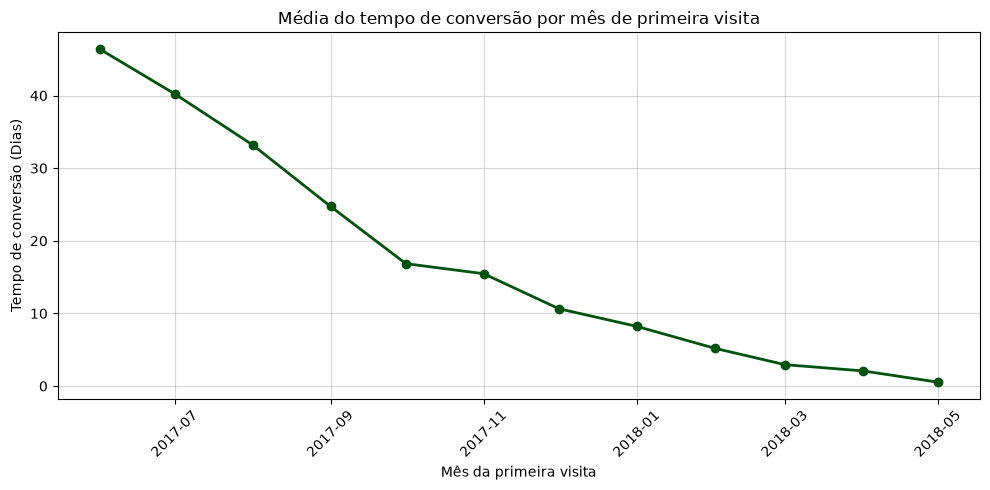

In [15]:
conversion_not_null['first_visit_month'] = conversion_not_null[
    'first_visit'
].dt.to_period('M')

# 2. Calcula a mediana do tempo de conversão por mês
conversion_monthly = (conversion_not_null.groupby('first_visit_month')['conversion_time'].mean().reset_index())
conversion_monthly['first_visit_month'] = conversion_monthly['first_visit_month'].dt.to_timestamp()

# 3. Plota o gráfico
plt.figure(figsize=(10, 5))
plt.plot(
    conversion_monthly['first_visit_month'],
    conversion_monthly['conversion_time'],
    marker='o',
    color='#00520E',
    linewidth=2,
)
# Configurações do gráfico
plt.title('Média do tempo de conversão por mês de primeira visita')
plt.xlabel('Mês da primeira visita')
plt.ylabel('Tempo de conversão (Dias)')
plt.grid(True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

O gráfico de média da conversão por mês mostra uma tendência de queda. Isso ocorre devido a como os dados estão alocados, por exemplo, a coorte de junho de 2017 tiveram 12 meses para registrar compras, enquanto a de março de 2018 toveram alguns dias

In [16]:
orders_log_df['month_order'] = orders_log_df['buy_ts'].dt.to_period('M') # Extrai o ano-mês
orders_per_month = orders_log_df.groupby(['month_order','uid']).agg({'uid':'count'}) # Extrai a quantidade de pedidos por cliente
orders_per_month.columns = ['qty']
orders_per_month = orders_per_month.reset_index()
# Essa divisão ocorre para cálculos futuros, um dataframe será para a quantidade de pedidos
# e o proximo será para ticket médio
orders_per_month_orders = orders_per_month.groupby('month_order').agg({'qty':['sum','mean']}).reset_index() # Extrai a quantidade total e a média de pedidos para cada mês
orders_per_month_orders.columns = ['month_order', 'total_order', 'mean_order']
orders_per_month_orders['pct_diff'] = ((orders_per_month_orders['total_order'].pct_change()) * 100).round(2) # Calcula a diferença percentual
orders_per_month_orders['pct_diff'] = pd.to_numeric(orders_per_month_orders['pct_diff'])

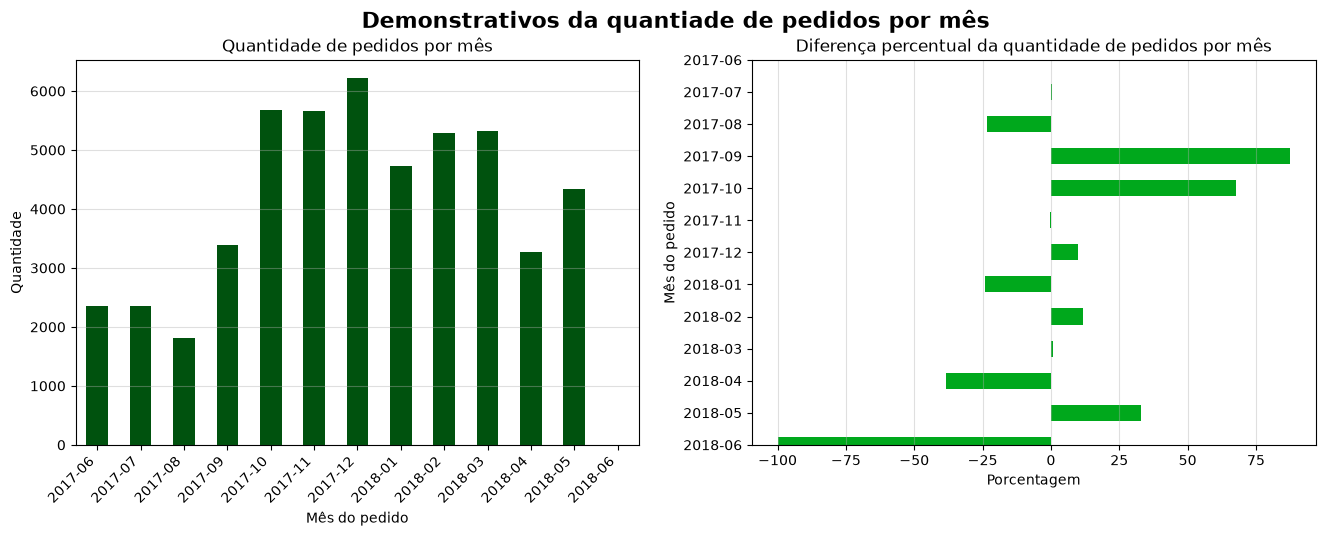

In [17]:
# Visualização da quantidade de pedidos por mês e a diferença percentual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
orders_per_month_orders.plot(kind='bar',
                             y='total_order',
                             x='month_order',
                             xlabel='Mês do pedido',
                             ylabel='Quantidade',
                             title='Quantidade de pedidos por mês',
                             color="#00520E",
                             ax=ax1)
ax1.legend().remove()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.4)
orders_per_month_orders.sort_values(by='month_order', ascending=False).plot(kind='barh',
                             y='pct_diff',
                             x='month_order',
                             xlabel='Porcentagem',
                             ylabel='Mês do pedido',
                             title='Diferença percentual da quantidade de pedidos por mês',
                             color="#00A81C",
                             ax=ax2)
ax2.legend().remove()
ax2.grid(axis='x', alpha=0.4)
plt.suptitle('Demonstrativos da quantiade de pedidos por mês',
             fontsize=16, fontweight='bold')
plt.show()

O mês de dezembro mostra forte dominio, impulsionado pelos eventos de final de ano.\
Cada cliente faz em média 1 pedido por mês.\
O ultimo mês representa uma queda de -99,98% pois teve apenas 1 compra registrada. \
isso se dá ao fato que a tabela original termina quando o mês começa, então não foram registradas vendas suficientes para análise completa.

In [18]:
orders_per_month_ticket = orders_log_df.groupby('month_order').agg(rev_mean=('revenue', 'mean'),
                                                                    rev_median=('revenue','median')).round(2).reset_index() # Extrai a média e a mediana da receita, para cada mês
orders_per_month_ticket['pct_diff_mean'] = (orders_per_month_ticket['rev_mean'].pct_change() * 100).round(2).fillna('-') # Calcula a diferença percentual da média
orders_per_month_ticket['pct_diff_median'] = (orders_per_month_ticket['rev_median'].pct_change() * 100).round(2).fillna('-') # Calcula a diferença percentual da mediana
order_columns = ['month_order', 'rev_mean', 'pct_diff_mean', 'rev_median', 'pct_diff_median']
orders_per_month_ticket = orders_per_month_ticket[order_columns] # Altera a ordem das colunas
orders_per_month_ticket['month_order'] = orders_per_month_ticket['month_order'].dt.to_timestamp()
display(orders_per_month_ticket)

,month_order,rev_mean,pct_diff_mean,rev_median,pct_diff_median
0,2017-06-01,4.06,-,2.44,-
1,2017-07-01,5.31,30.79,3.05,25.0
2,2017-08-01,4.85,-8.66,2.78,-8.85
3,2017-09-01,5.42,11.75,2.44,-12.23
4,2017-10-01,4.93,-9.04,2.44,0.0
5,2017-11-01,4.78,-3.04,2.44,0.0
6,2017-12-01,5.85,22.38,2.69,10.25
7,2018-01-01,4.11,-29.74,2.44,-9.29
8,2018-02-01,4.84,17.76,2.69,10.25
9,2018-03-01,5.41,11.78,2.44,-9.29


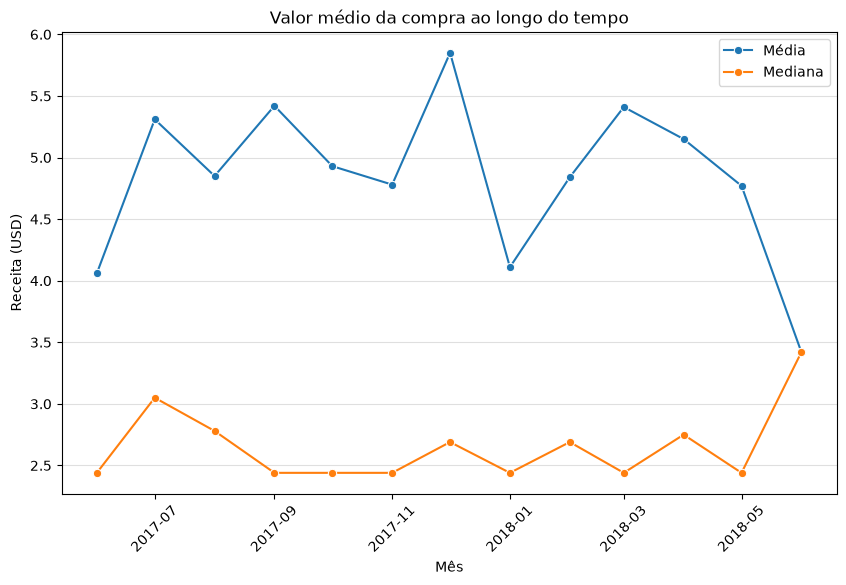

In [19]:
# Visualização do volume de pedidos ao longo do tempo
plt.figure(figsize=(10,6))
sns.lineplot(data=orders_per_month_ticket, x='month_order', y='rev_mean', marker='o', label='Média')
sns.lineplot(data=orders_per_month_ticket, x='month_order', y='rev_median', marker='o', label='Mediana')
plt.title('Valor médio da compra ao longo do tempo')
plt.xlabel('Mês')
plt.ylabel('Receita (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.4)
plt.legend()
plt.show()

O volume médio das compras fica entre 4 e 5 dólares por mês. Já o volume mediano fica entre 2 e 3 doláres por mês.\
Os valores médios sendo maiores que o medianos, indica que eventualmente algum cliente faz alguma compra maior que os demais.\
O valor final onde se encontram (~3.40), se dá pelo fato do mes de junho de 2018 ter apenas 1 compra registrada, que seria exatamente onde os dados acabam.

In [20]:
# Formata a tabela 'first_order' para evitar erros futuros
first_order = first_order.reset_index()
first_order.columns = ['uid', 'first_order_month']
first_order['first_order_month'] = first_order['first_order_month'].dt.to_period('M')

In [21]:
cohort_sizes = first_order.groupby('first_order_month')['uid'].nunique().reset_index() # Os primeiros meses por ID
cohort_sizes.columns = ['first_order_month','n_buyers']
margin_rate = 0.5 # Define a margem de lucro
orders = pd.merge(orders_log_df, first_order, on='uid') # cria um dataframe com os pedidos e o mês da primeira compra
cohorts = orders.groupby(['first_order_month', 'month_order'])['revenue'].sum().reset_index() # agrupa os pedidos por mês de primeira compra e mês do pedido, somando a receita
report = pd.merge(cohort_sizes, cohorts, on='first_order_month') # unindo os dataframes de tamanho da coorte e receita, para que seja possivel calcular o LTV
report['gp'] = report['revenue'] * margin_rate # Calcula o lucro bruto
report['age'] = (report['month_order'] - report['first_order_month']).apply(lambda x: x.n) # Calcula a idade da coorte
report['ltv'] = report['gp'] / report['n_buyers'] # Calcula o LTV
report = report.sort_values(by=['first_order_month', 'age'])
report['ltv'] = report.groupby('first_order_month')['ltv'].cumsum()

In [22]:
# Cria uma tabela dinâmica para visualizar o LTV médio por idade e mês da primeira compra
result = report.pivot_table(
    index='first_order_month',
    columns='age',
    values='ltv',
    aggfunc='mean'
).round(2)

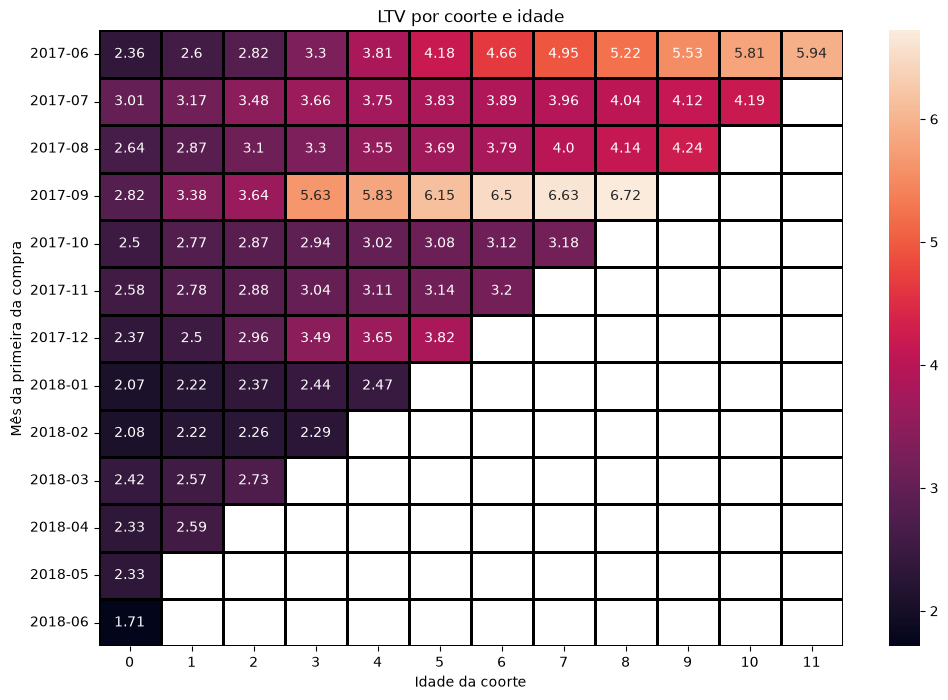

In [23]:
# Visualização do LTV por coorte e idade
plt.figure(figsize=(12, 8))
sns.heatmap(result,
    annot=True,
    fmt='',
    linewidths=1,
    linecolor='black'
)
plt.xlabel('Idade da coorte')
plt.ylabel('Mês da primeira da compra')
plt.title('LTV por coorte e idade')
plt.show()

## Conclusão das métricas para o vendas

A maior parte dos clientes efetuam a primeira compra logo após o registro, isso é um bom sinal, porém os que não efetuam, demoram em média 60 dias, o que leva a esse comportamento? A promoção não agradou o cliente? algo relacionado com a entrega?\
O último trimestre de 2017 é impulsionado pelos eventos de final de ano, porém logo após, a quantidade de vendas em janeiro de 2018 caiu em 24% em relação a dezembro, pelo visto as festas acabaram.\
O volume médio das compras teve alta apenas em dezembro de 2017, e também teve uma queda notável de quase 30%\
O valor do tempo de vida do cliente nos mostra que nos ultimos 6 meses o pessoal que efetou sua primeira compra em  setembro de 2017 foram os que mais trouxeram lucro para a empresa.\
Entre junho e Agosto, o LTV médio seguiu com forte alta, porém após os recordes de setembro, nenhum grupo de clientes entregou mais de 4$ de lucro bruto a empresa.


### Calculo de métricas - MARKETING

In [24]:
costs_df['month'] = costs_df['dt'].dt.to_period('M') # Extrai o ano-mes
costs_by_source_total = costs_df.groupby('source_id')['costs'].sum().reset_index() # Obtem os gastos totais por origem
costs_by_source_total.columns = ['source_id', 'total_costs']
print(f"Gasto total em marketing: {costs_df['costs'].sum()} USD") # Exibe os gastos totais
costs_by_month = costs_df.groupby('month')['costs'].sum().reset_index() # Obtem os gastos por ano-mes
costs_by_month.columns = ['month', 'total_costs']

Gasto total em marketing: 329131.62 USD


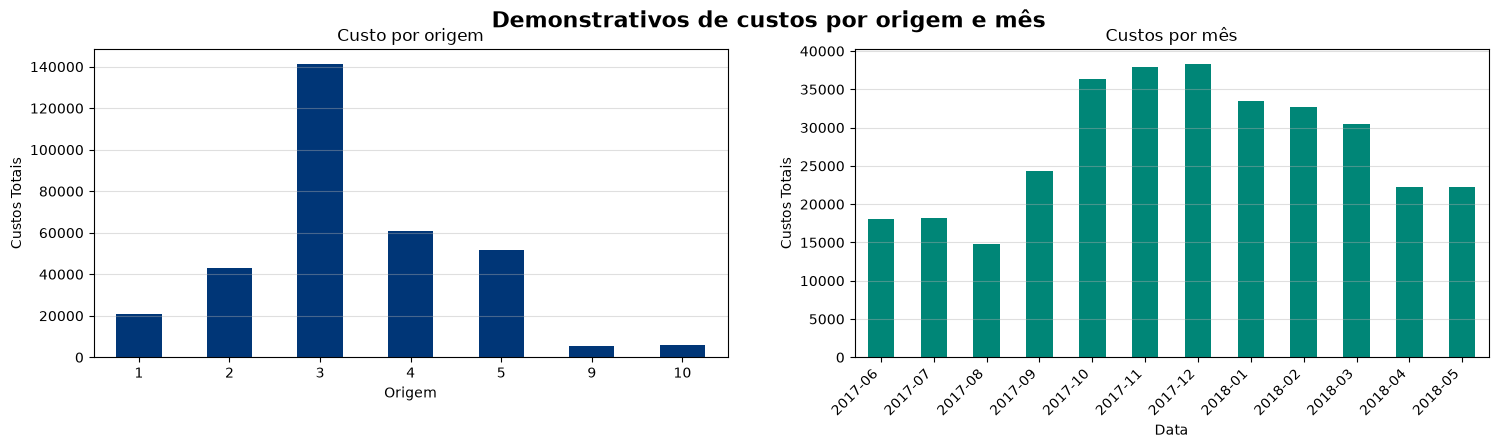

In [25]:
# Visualização dos gastos por origem e mês
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,4))
costs_by_source_total.plot(kind='bar',
                           y='total_costs',
                           x='source_id',
                           rot=0,
                           xlabel='Origem',
                           ylabel='Custos Totais',
                           title='Custo por origem',
                           color="#003677",
                           ax=ax1)
ax1.legend().remove()
ax1.grid(axis='y', alpha=0.4)
costs_by_month.plot(kind='bar',
                    y='total_costs',
                    x='month',
                    xlabel='Data',
                    ylabel='Custos Totais',
                    title='Custos por mês',
                    color='#008677',
                    ax=ax2)
ax2.legend().remove()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.4)
plt.suptitle('Demonstrativos de custos por origem e mês',
             fontsize=16, fontweight='bold')
plt.show()

O gasto total com marketing foi de 329.131,62 USD.\
Os gráficos mostram que a origem 3 foi a que mais recebeu investimento em propaganda.\
De outubro de 2017 até Março de 2018 gasto com marketing ficou acima dos 30 mil.

In [26]:
costs_by_source = costs_df.groupby(['source_id', 'month'])['costs'].sum().reset_index() # Agrupa origem e ano-mes pelo total dos custos
# Une as duas tabelas, onde os registros da primeira tabela são combinados com os registros da segunda tabela com base nas chaves especificadas
cac_visits_df = pd.merge(visits_log_df, first_visit, on=['uid', 'start_ts'], how='inner').drop_duplicates(subset=['uid'], keep='first')
# O drop_duplicates() foi feito para garantir que não há id's duplicados
cac_visits_df = cac_visits_df.drop(columns=['end_ts', 'session_year', 'session_month_period', 'session_week', 'session_date', 'session_length']) # Remove as colunas que não serão mais utilizadas

In [27]:
aquis_cost = pd.merge(cac_visits_df, first_order, on='uid', how='inner')
aquis_cost['visit_month'] = aquis_cost['start_ts'].dt.to_period('M')  # mês em que foi impactado pelo investimento
aquis_cost = aquis_cost.groupby(['source_id', 'visit_month'])['uid'].nunique().reset_index()
aquis_cost.columns = ['source_id', 'month', 'n_buyers']
aquis_cost = pd.merge(aquis_cost, costs_by_source, on=['source_id', 'month'])
aquis_cost['cac'] = aquis_cost['costs'] / aquis_cost['n_buyers']

In [28]:
# Cria uma tabela dinâmica para visualizar o CAC médio por origem e mês
result_cac = aquis_cost.pivot_table(
    index='month',
    columns='source_id',
    values='cac',
    aggfunc='mean'
).round(2)

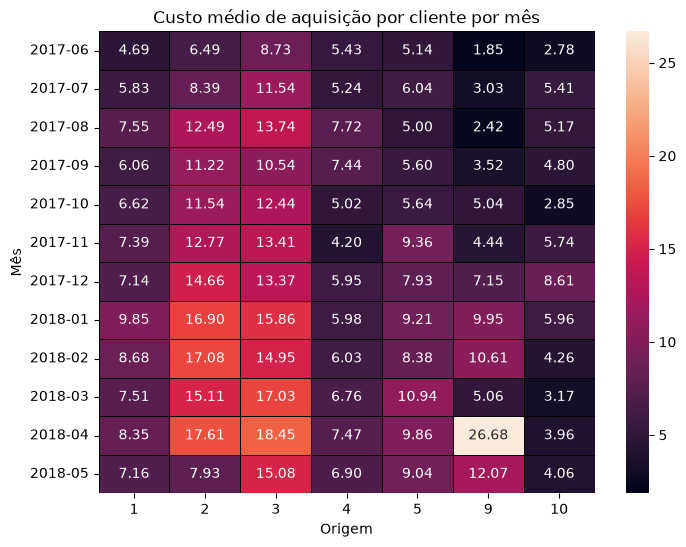

In [29]:
# Visualização do CAC médio por origem e mês
plt.figure(figsize=(8, 6))
sns.heatmap(result_cac,
            annot=True,
            fmt='.2f',
            linewidths=0.5,
            linecolor='black')
plt.xlabel('Origem')
plt.ylabel('Mês')
plt.title('Custo médio de aquisição por cliente por mês')
plt.show()

A origem 3 se destaca sendo a mais cara dentre as outras (8-18 por cliente), em contrapartida a origem 10 é a mais barata (2-8 por cliente).\
A origem 9 teve um pico em abril de 2018, superando todos os valores das outras origens (26.68). Isso tem alguma relação com a anomalia decetada anteriormente?\
O restante das origens se mantiveram moderadamente estáveis.

In [30]:
aquis_cost_filtered = aquis_cost[aquis_cost['source_id'] == 9] # Filtra os dados para a origem 9, que é a origem com maior investimento
print(aquis_cost_filtered) # Exibe os dados filtrados, afim de estudar o CAC da origem 9, que possui uma anomalia de investimento em março de 2018

    source_id    month  n_buyers   costs        cac
60          9  2017-06       154  285.22   1.852078
61          9  2017-07       100  302.54   3.025400
62          9  2017-08       103  248.93   2.416796
63          9  2017-09       118  415.62   3.522203
64          9  2017-10       121  609.41   5.036446
65          9  2017-11       154  683.18   4.436234
66          9  2017-12        92  657.98   7.151957
67          9  2018-01        55  547.16   9.948364
68          9  2018-02        52  551.50  10.605769
69          9  2018-03        95  480.29   5.055684
70          9  2018-04        14  373.49  26.677857
71          9  2018-05        30  362.17  12.072333


Estudando o caso mais de perto, podemos concluir que o valor de 26.68 tem relação com o apagão visto anteriormente.\
Isso acontece por que o número de usuário cai, porém os custos se mantém na mesma média dos meses anteriores, isso distorçe o cálculo final.\
Recomenda-se desconsiderar esse ponto específico em análises de tendência de CAC.

In [31]:
base_source = pd.merge(cac_visits_df, first_order, on='uid') # unindo os dataframes de visitas e primeira compra, para que seja possivel calcular o CAC
cohort_sizes_source = base_source.groupby(['source_id', 'first_order_month'])['uid'].nunique().reset_index() # Agrupa origem e ano-mes pelo total de compradores
orders_source = pd.merge(orders_log_df, base_source, on='uid') # unindo os dataframes de pedidos e primeira compra, para que seja possivel calcular o LTV
cohorts_source = orders_source.groupby(['source_id', 'first_order_month', 'month_order'])['revenue'].sum().reset_index() # Agrupa os dados por origem, mês de primeira compra e mês de pedido, e calcula o faturamento total para cada grupo

In [32]:
report_source = pd.merge(cohort_sizes_source, cohorts_source, on=['source_id', 'first_order_month']) # unindo os dataframes de tamanho da coorte e receita, para que seja possivel calcular o LTV
report_source = report_source.rename(columns={'uid':'n_buyers'})
# Repete o mesmo processo feito anteriormente, mas agora por origem de aquisição
report_source['gp'] = report_source['revenue'] * margin_rate
report_source['age'] = (report_source['month_order'] - report_source['first_order_month']).apply(lambda x: x.n)
report_source['ltv'] = report_source['gp'] / report_source['n_buyers']
report_source = report_source.sort_values(by=['first_order_month', 'age', 'source_id'])
report_source['ltv'] = report_source.groupby(['first_order_month', 'source_id'])['ltv'].cumsum()

In [33]:
# Cria uma função para calcular o ROI para cada origem de aquisição, por idade da coorte
def roi_calc(df, aquis_df):
    cac_df = aquis_df.copy()
    cac_df['cac'] = cac_df['costs'] / cac_df['n_buyers']
    
    roi_final = cac_df[['source_id']].copy()
    for i in range(0, 12):
        ltv_i = df[df['age'] == i].groupby('source_id')['ltv'].mean().reset_index()
        temp = pd.merge(ltv_i, cac_df[['source_id', 'cac']], on='source_id', how='left')
        temp[f'{i}'] = temp['ltv'] / temp['cac']
        roi_final = pd.merge(roi_final, temp[['source_id', f'{i}']], on='source_id', how='left')
    
    return roi_final

roi_by_age = roi_calc(report_source, aquis_cost.groupby('source_id').agg({'costs':'sum', 'n_buyers':'sum'}).reset_index())
roi_by_age = roi_by_age.set_index('source_id')

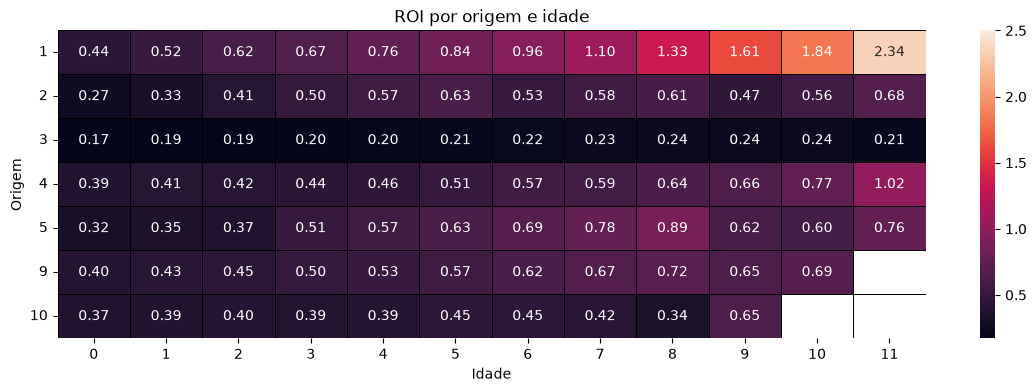

In [34]:
# Visualização do ROI por origem e idade
plt.figure(figsize=(14,4))
sns.heatmap(data=roi_by_age,
            annot=True,
            fmt='.2f',
            linecolor='black',
            linewidths=0.5,
            vmax=2.5)
plt.xlabel('Idade')
plt.ylabel('Origem')
plt.title('ROI por origem e idade')
plt.yticks(rotation=0)
plt.show()

A tabela mostra a origem 1 sendo a mais provável a pagar os custos, enquanto a origem 3 não se mostra propensa ao mesmo feito.

In [35]:
aquis_cost['month'] = aquis_cost['month'].dt.to_timestamp() # Converte a coluna 'month' para o tipo datetime
aquis_cost['source_id'] = aquis_cost['source_id'].astype('category') # Converte a coluna 'source_id' para o tipo categórico

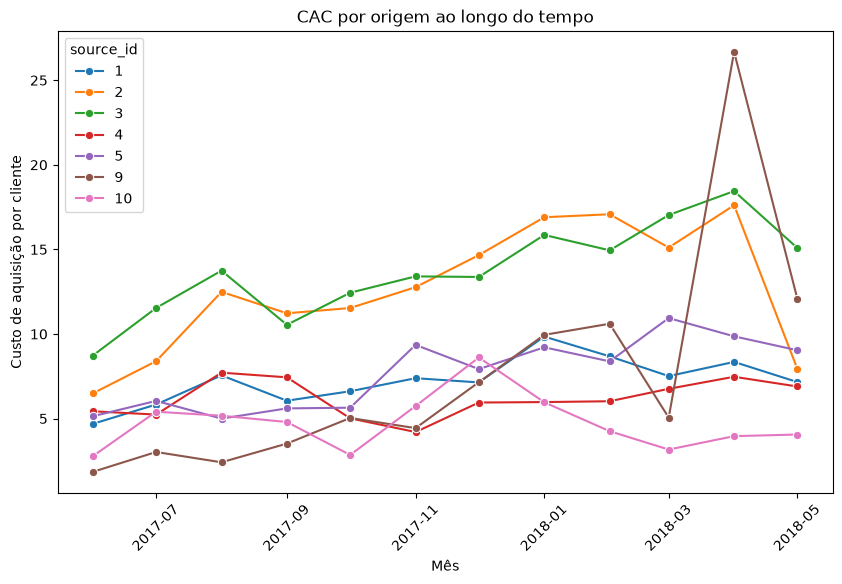

In [36]:
# Visualização do CAC por origem ao longo do tempo
plt.figure(figsize=(10,6))
sns.lineplot(data=aquis_cost,
             x='month',
             y='cac',
             hue='source_id',
             marker='o')
plt.title('CAC por origem ao longo do tempo')
plt.xlabel('Mês')
plt.ylabel('Custo de aquisição por cliente')
plt.xticks(rotation=45)
plt.show()

As origens de número 2 e 3 demonstram tendência de alta.\
A alta repentina da origem 9, se dá pela anomalia no sistema de logs detectada anteriormente.

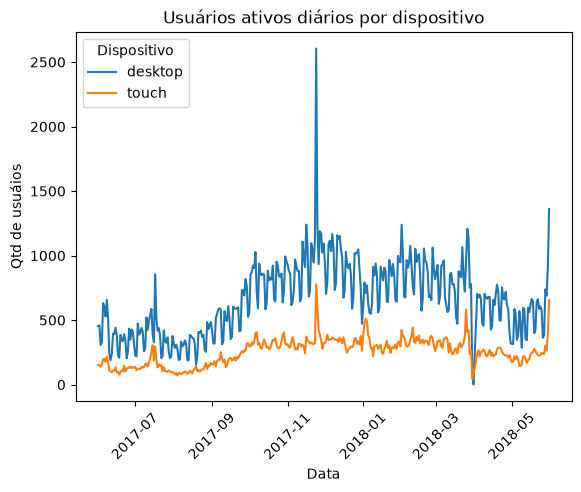

In [37]:
# Visualização do DAU por dispositivo ao longo do tempo
device_dau = visits_log_df.groupby(['session_date','device'])['uid'].nunique().reset_index()
sns.lineplot(data=device_dau,
             x='session_date', 
             y='uid', 
             hue='device')
plt.title('Usuários ativos diários por dispositivo')
plt.xlabel('Data')
plt.ylabel('Qtd de usuáios')
plt.legend(title='Dispositivo', loc='upper left')
plt.xticks(rotation=45)
plt.show()

Os usuário de desktop demonstram dominio a todo momento.\
Ambas plataformas tiveram pico no mês de dezembro devido as festas de fim de ano.\
Confirma-se que queda em março/abril de 2018 foi uma possível manutenção ou inconsistência no sistema de logs.

## Conclusão das métricas para o marketing

Setembro e outubro tiveram mais investimento em marketing se preparando para o fim de ano, e logo após em janeiro, a quedas foram contínuas. Por que houve essa redução? Não foi oferecido nenhuma promoção pós fim de ano?\
O que diferencia a origem 3 (mais cara) da 10 (mais barata)? O que podemos fazer para atrair mais clientes da origem 10? A origem 2 tem alguma relação com 3, ambas tiveram valores proximos, o que justifica isso?\
O pico na origem 9 é justificado pela anomalia nos logs detectado no início das análises, em prol disso, ele não tem impacto na conclusão geral sobre as demais origens.\
Nenhuma origem se pagou em 10 meses, em exceção da primeira. O que tem diferencia ela das outras?\
Para a origem 1, ela se paga nas idades mais avançadas, o que chamou a atenção dos clientes?\
Os usuários touch não apresentam muito interesse comparado aos do desktop, o que leva a isso? a versão mobile possui algum problema? Isso varia de dispositivo para dispositivo?

# Conclusão geral - Recomendações

**Quais origens você recomendaria?**

A origem 1 é a mais eficiente, com menor custo relativo, maior LTV, e é a que mais rápido atinge ROI > 1. A origem 4 também se paga, mas só no último mês — porém com números consideráveis.\
As origens 3 e 10 devem ser revisadas com prioridade, a 3 é a que recebeu mais investimento e nunca ultrapassa ROI de 0.3 em nenhuma idade. A origem 10, mesmo sendo uma das mais baratas de adquirir, também não se paga.

**Em quais métricas você se concentrou? Por quê?**

O foco foi no ROI como métrica final, pois o CAC e LTV isolados não contam a história completa: uma origem pode ser barata mas trazer clientes de baixo valor, ou ter LTV alto mas custar caro demais pra valer a pena. Só o ROI junta os dois extremos.\
Foi calculado o ROI para cada idade da coorte (0 a 11 meses) — isso mostrou que o retorno de marketing nesse produto é de médio/longo prazo, e não imediato.
O gráfico de evolução temporal do CAC por origem também ajudou a confirmar que os custos de aquisição não são estáveis. A origem 3, por exemplo, se manteve cara durante quase todo o período.

**Que conclusões você tirou?**

- Os usuários de desktop dominam o engajamento sobre os de touch/mobile.
- A versão mobile levantou uma serie de questões sobre funcionamento e otimização, deve ser revisado se não há algum problema, botão falhando, ou algum problema na interface. Com isso possivelmente teremos mais acessos.
- Estudar a possiblidade de eventos mensais ou cupons promocionais, para que chame mais a atenção dos clientes
- A maioria das origens leva entre 6 e 11 meses para recuperar o custo de aquisição em lucro bruto.
- A origem 3, foi uma das que mais recebeu investimento, e foi a que trouxe o pior retorno em toda o tempo.
- A origem 1, mais barata e com LTV mais alto, é a combinação ideal, um passo interessante seria realocar parte dos invetimentos da origem para lá
- Setembro e outubro tiveram o maior investimento em marketing (provavelmente preparação para o fim de ano), mas a origem que mais se destacou em retorno não foi necessariamente a que mais recebeu investimento nesse período, nesse caso, vale investigar se o orçamento da origem 1 está alinhado com o que realmente performa.
